In [104]:
import numpy as np
import cvxpy as cvx
from sklearn.datasets import make_classification
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

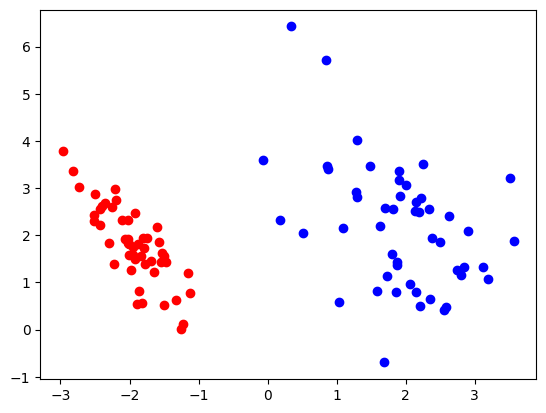

In [105]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2.0,
    flip_y=0.0,
    random_state=2,
)

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="red")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="blue")
plt.show()

In [106]:
y = 2 * y - 1
y = y.astype(np.float32)

n_points, n_features = X.shape

alpha = cvx.Variable(n_points)
H = y.reshape(-1, 1) * y.reshape(1, -1) * (X @ X.T)

objective = cvx.Maximize(
    cvx.sum(alpha) - 0.5 * cvx.quad_form(alpha, H, assume_PSD=True)
)
constraints = [alpha >= 0, alpha @ y == 0]

problem = cvx.Problem(objective, constraints)
result = problem.solve()

w = (alpha.value * y) @ X
b = -0.5 * (np.max(X[y < 0] @ w) + np.min(X[y > 0] @ w))

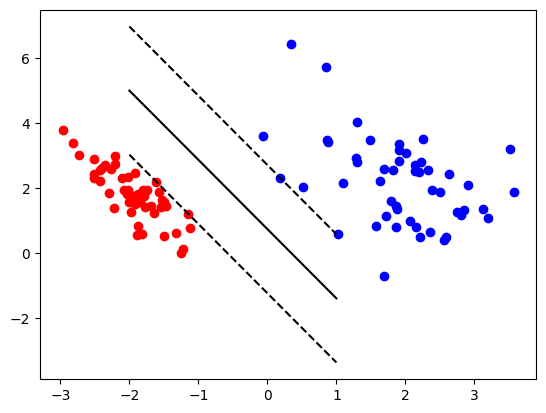

In [113]:
plt.scatter(X[y < 0][:, 0], X[y < 0][:, 1], color="red")
plt.scatter(X[y > 0][:, 0], X[y > 0][:, 1], color="blue")
# display wx + b
x = np.linspace(-2, 1, 100)
plt.plot(x, (-w[0] * x - b) / w[1], color="black")
plt.plot(x, (-w[0] * x - b + 1) / w[1], color="black", linestyle="--")
plt.plot(x, (-w[0] * x - b - 1) / w[1], color="black", linestyle="--")
plt.show()